# M11: SVD Feature Engineering + Prediction Interval Assessment

## Overview
This notebook implements **Nyström KernelPCA** embeddings of the 61-dimensional cost-type histogram vectors as additional features for the merchant processing cost prediction pipeline.

### Experimental Design
| Phase | Content |
|-------|---------|
| **A** | Nyström SVD generation: 3 kernels (cosine · RBF-L2 · Jensen-Shannon) |
| **B** | Baseline pipeline: M8 (flat pool) · M9 (cosine kNN) · M10 (deviation) with conformal intervals |
| **C** | SVD-augmented models: M11 (4+SVD features) vs M12 (SVD-only), per kernel · CQR |
| **D** | Results: Winkler score table · eigenvalue decay · forecast fan chart |

### Key Benchmarks
- **M9** Winkler = 112.65 pp  
- **M9-CQR** Winkler = 73.21 pp ← target to beat with SVD features

## Phase A — SVD Feature Generation

### A1 — Imports & Configuration

In [25]:
import os, math, warnings, itertools
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler, normalize as sk_normalize
from sklearn.linear_model import HuberRegressor, QuantileRegressor
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


In [ ]:
# ── Pipeline constants (must match m8_pipeline_c1 copy.ipynb) ──────────────────
CONTEXT_LEN   = 1
HORIZON_LEN   = 3
TARGET_COV    = 0.90
KNN_K         = 10
MIN_POOL      = 10
VOL_THRESHOLD = 0.15
VOL_LABELS    = ['Low', 'High']
_VOL_EPS      = 1e-6

# ── SVD constants ──────────────────────────────────────────────────────────────
SVD_RANK      = 20
N_LANDMARKS   = 500
COST_TYPE_COLS = [f'cost_type_{i}_pct' for i in range(1, 62)]   # 61 cols

# ── Paths ──────────────────────────────────────────────────────────────────────
_HERE = Path('.')   # notebook working directory
DATA_IN  = 'df_5411_merchants_samplemthly_26th_Mar.csv'
DATA_SVD = 'df_5411_merchants_samplemthly_svd.csv'

print(f'COST_TYPE_COLS: {len(COST_TYPE_COLS)} columns')
print(f'SVD rank={SVD_RANK}  landmarks={N_LANDMARKS}')
print(f'Target coverage={TARGET_COV}  context={CONTEXT_LEN}  horizon={HORIZON_LEN}')

COST_TYPE_COLS: 61 columns
SVD rank=20  landmarks=500
Target coverage=0.9  context=1  horizon=3


### A2 — Load Data & Fingerprint Preparation

In [27]:
sample_merchants = pd.read_csv(DATA_IN)
print(f'Loaded: {sample_merchants.shape}  |  merchants: {sample_merchants["merchant_id"].nunique()}')
print(f'Years: {sorted(sample_merchants["year"].unique())}')
print(f'Columns sample: {list(sample_merchants.columns[:8])} ...')

# Verify all 61 cost-type columns exist
_missing_ct = [c for c in COST_TYPE_COLS if c not in sample_merchants.columns]
assert len(_missing_ct) == 0, f'Missing cost-type columns: {_missing_ct}'
print(f'All {len(COST_TYPE_COLS)} cost-type columns present ✓')

Loaded: (33007, 72)  |  merchants: 2000
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Columns sample: ['merchant_id', 'year', 'month', 'transaction_count', 'avg_proc_cost_pct', 'total_processing_value', 'median_proc_cost_pct', 'cost_type_1_pct'] ...
All 61 cost-type columns present ✓


In [28]:
# ── Fingerprint matrices ────────────────────────────────────────────────────────
H_raw  = sample_merchants[COST_TYPE_COLS].fillna(0).values.astype(np.float64) + 1e-9
# Probability simplex (rows sum to 1) — used for JS divergence
H_prob = H_raw / H_raw.sum(axis=1, keepdims=True)
# L2-normalised — used for cosine & RBF-L2 kernels
H_l2   = sk_normalize(H_prob, norm='l2')

# ── Temporal leakage guard: SVD landmarks built only from "training years" ─────
_all_years = sorted(sample_merchants['year'].unique())
SVD_TRAIN_MAX_YEAR = _all_years[int(len(_all_years) * 0.70) - 1]
_train_mask = sample_merchants['year'].values <= SVD_TRAIN_MAX_YEAR

print(f'H_prob shape : {H_prob.shape}')
print(f'H_l2  shape  : {H_l2.shape}')
print(f'SVD_TRAIN_MAX_YEAR = {SVD_TRAIN_MAX_YEAR}  '
      f'({_train_mask.sum():,} rows in training fingerprint set)')

H_prob shape : (33007, 61)
H_l2  shape  : (33007, 61)
SVD_TRAIN_MAX_YEAR = 2016  (23,270 rows in training fingerprint set)


### A3 — Landmark Selection & Kernel Functions

In [29]:
_rng_lm = np.random.default_rng(42)
_train_idx = np.where(_train_mask)[0]
_n_lm = min(N_LANDMARKS, len(_train_idx))
_lm_idx = _rng_lm.choice(_train_idx, size=_n_lm, replace=False)

# Landmark matrices (select from correct representation per kernel)
H_lm_l2   = H_l2[_lm_idx]     # cosine + RBF-L2
H_lm_prob  = H_prob[_lm_idx]   # Jensen-Shannon

# ── Median heuristic bandwidth for RBF-L2 ─────────────────────────────────────
_dists_lm = cdist(H_lm_l2[:200], H_lm_l2[:200], metric='euclidean').ravel()
_sigma_rbf = float(np.median(_dists_lm[_dists_lm > 0]))
print(f'n_landmarks={_n_lm}  σ_rbf={_sigma_rbf:.4f}')

# ── Kernel functions ───────────────────────────────────────────────────────────
def _cosine_kernel(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Cosine similarity kernel: K_ij = A_i · B_j  (L2-normalised inputs)."""
    return A @ B.T

def _rbf_l2_kernel(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """RBF kernel on L2-normalised inputs with median bandwidth."""
    D2 = cdist(A, B, metric='sqeuclidean')
    return np.exp(-D2 / (2.0 * _sigma_rbf ** 2))

def _js_kernel(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Exponentiated Jensen-Shannon kernel on probability vectors."""
    n, m = A.shape[0], B.shape[0]
    K = np.empty((n, m), dtype=np.float64)
    for i in range(n):
        M = 0.5 * (A[i] + B)
        eps = 1e-12
        js = (
            0.5 * np.sum(A[i] * np.log(A[i] / (M + eps) + eps), axis=1) +
            0.5 * np.sum(B * np.log(B / (M + eps) + eps), axis=1)
        )
        K[i] = np.exp(-js)
    return K

# ── Metric configuration dict ─────────────────────────────────────────────────
# (H_lm, H_all, kernel_fn) — the arrays to use for each metric
_METRICS = {
    'cosine':  (H_lm_l2,   H_l2,    _cosine_kernel),
    'rbf_l2':  (H_lm_l2,   H_l2,    _rbf_l2_kernel),
    'js':      (H_lm_prob,  H_prob,  _js_kernel),
}
print('Kernel functions defined:', list(_METRICS.keys()))

n_landmarks=500  σ_rbf=1.3716
Kernel functions defined: ['cosine', 'rbf_l2', 'js']


### A4 — Nyström Embedding & Eigenvalue Decay

In [30]:
def nystrom_embed(
    H_all: np.ndarray,
    H_lm: np.ndarray,
    kernel_fn,
    rank: int,
    eps: float = 1e-9
):
    """
    Nyström approximation of KernelPCA with `rank` dimensions.

    Parameters
    ----------
    H_all    : (n, d) all row fingerprints
    H_lm     : (m, d) landmark fingerprints (m << n)
    kernel_fn: callable(A, B) -> (n_A, n_B) kernel matrix
    rank     : target embedding dimension
    eps      : regularisation added to diagonal of K_mm

    Returns
    -------
    Phi      : (n, rank) row embeddings
    eigvals  : (m,) eigenvalues of K_mm (sorted ascending by np.linalg.eigh)
    """
    m = H_lm.shape[0]
    K_mm = kernel_fn(H_lm, H_lm)                     # (m, m)
    K_mm += eps * np.eye(m)

    eigvals, eigvecs = np.linalg.eigh(K_mm)           # ascending order
    # Keep only positive eigenvalues (clip numerically negative ones)
    pos_mask = eigvals > 0
    L = eigvals[pos_mask]
    V = eigvecs[:, pos_mask]

    # Take top `rank` (highest eigenvalues are at the end after eigh)
    r = min(rank, L.shape[0])
    L_r = L[-r:]
    V_r = V[:, -r:]

    K_nm = kernel_fn(H_all, H_lm)                     # (n, m)
    Phi = K_nm @ V_r / np.sqrt(L_r)                   # (n, r)

    return Phi, eigvals


print('nystrom_embed() defined')

nystrom_embed() defined


  Running cosine ... Phi shape=(33007, 20)  |  top-3 eigvals=[144.57   83.873  54.271]
  Running rbf_l2 ... Phi shape=(33007, 20)  |  top-3 eigvals=[339.418  33.964  23.458]
  Running js ... Phi shape=(33007, 20)  |  top-3 eigvals=[304.544  37.117  25.013]
cosine: components for 80% variance = 6
rbf_l2: components for 80% variance = 4
js: components for 80% variance = 5


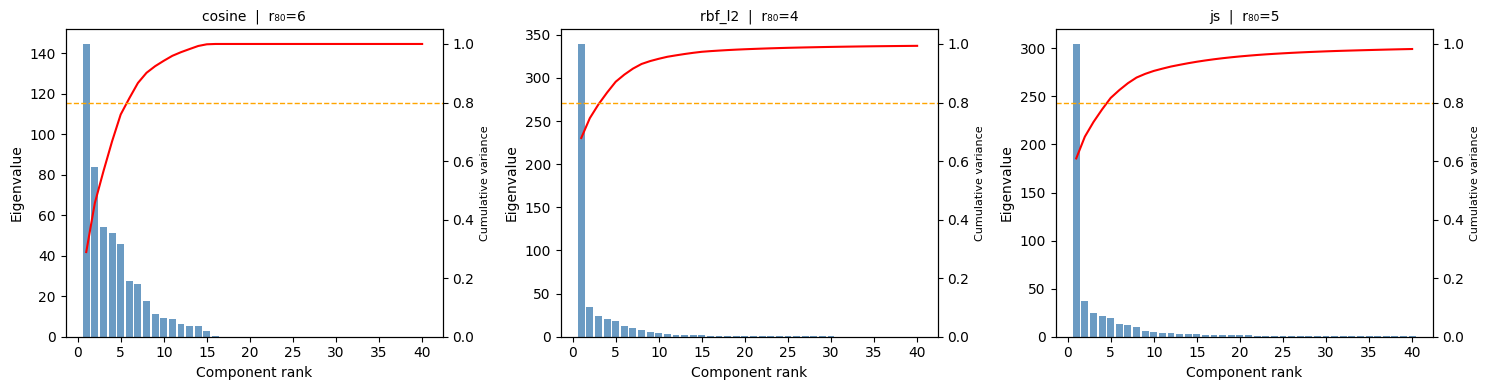

In [31]:
# ── Run Nyström for each kernel ──────────────────────────────────────────────────
_svd_results = {}   # metric -> (Phi, eigvals)
for _metric, (H_lm_k, H_all_k, kfn) in _METRICS.items():
    print(f'  Running {_metric} ...', end=' ')
    _Phi, _eig = nystrom_embed(H_all_k, H_lm_k, kfn, rank=SVD_RANK)
    _svd_results[_metric] = (_Phi, _eig)
    print(f'Phi shape={_Phi.shape}  |  top-3 eigvals={_eig[-3:][::-1].round(3)}')

# ── Eigenvalue decay + cumulative variance — 3-panel figure ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, _metric in zip(axes, _METRICS):
    _eig = _svd_results[_metric][1]
    _pos = np.sort(_eig[_eig > 0])[::-1]   # descending
    _cumvar = np.cumsum(_pos) / _pos.sum()
    _r80 = int(np.searchsorted(_cumvar, 0.80)) + 1
    ax.bar(range(1, min(41, len(_pos)+1)), _pos[:40], color='steelblue', alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(range(1, min(41, len(_pos)+1)), _cumvar[:40], 'r-', lw=1.5)
    ax2.axhline(0.80, color='orange', ls='--', lw=1, label='80%')
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Cumulative variance', fontsize=8)
    ax.set_title(f'{_metric}  |  r₈₀={_r80}', fontsize=10)
    ax.set_xlabel('Component rank')
    ax.set_ylabel('Eigenvalue')
    print(f'{_metric}: components for 80% variance = {_r80}')
plt.tight_layout()
plt.show()

### A5 — Append SVD Columns & Save Augmented CSV

In [32]:
df_svd = sample_merchants.copy()

SVD_COLS = []
for _metric, (_Phi, _) in _svd_results.items():
    for k in range(SVD_RANK):
        col = f'svd_{_metric}_{k+1}'
        df_svd[col] = _Phi[:, k].astype(np.float32)
        SVD_COLS.append(col)

df_svd.to_csv(DATA_SVD, index=False)
print(f'Saved {DATA_SVD}  shape={df_svd.shape}')
print(f'SVD columns ({len(SVD_COLS)}): {SVD_COLS[:6]} ... {SVD_COLS[-3:]}')
df_svd.head(3)

Saved df_5411_merchants_samplemthly_svd.csv  shape=(33007, 132)
SVD columns (60): ['svd_cosine_1', 'svd_cosine_2', 'svd_cosine_3', 'svd_cosine_4', 'svd_cosine_5', 'svd_cosine_6'] ... ['svd_js_18', 'svd_js_19', 'svd_js_20']


,merchant_id,year,month,transaction_count,avg_proc_cost_pct,total_processing_value,median_proc_cost_pct,cost_type_1_pct,cost_type_2_pct,cost_type_3_pct,...,svd_js_11,svd_js_12,svd_js_13,svd_js_14,svd_js_15,svd_js_16,svd_js_17,svd_js_18,svd_js_19,svd_js_20
0,5,2011,9,3,3.3087,27.0600,3.4701,0.0000,0.0000,0.0000,...,0.0155,0.1111,0.2662,-0.0101,-0.1250,0.0581,0.2645,0.1242,0.2796,-0.7856
1,5,2011,11,1,4.3715,5.6400,4.3715,0.0000,0.0000,0.0000,...,-0.0627,-0.0886,0.0578,0.0271,-0.0448,0.0571,0.3591,0.2115,0.3668,-0.8065
2,5,2012,12,9,2.2136,145.7500,2.2293,0.0000,0.0000,0.0000,...,-0.0594,-0.0208,-0.2404,-0.3258,-0.4895,0.1264,-0.0528,-0.0743,-0.0908,-0.6879


---
## Phase B — Baseline Pipeline (M8 · M9 · M10)

Compressed reproduction of the M8 pipeline from `m8_pipeline_c1 copy.ipynb`.  
All helper functions are identical; only comments are shortened for brevity.

### B1 — Helper Functions

In [33]:
def get_test_scenario(df, merchant_id, context_len, horizon_len):
    """
    Return all valid (context, horizon) window pairs for a merchant.
    Windows slide over consecutive rows in the merchant's sorted record.
    ctx_hor_gap == 0 enforced (horizon starts immediately after context).
    """
    md = df[df['merchant_id'] == merchant_id].sort_values(['year', 'month']).reset_index(drop=True)
    if len(md) < context_len + horizon_len:
        return []
    scenarios = []
    for i in range(len(md) - context_len - horizon_len + 1):
        ctx = md.iloc[i : i + context_len].copy().reset_index(drop=True)
        hor = md.iloc[i + context_len : i + context_len + horizon_len].copy().reset_index(drop=True)
        scenarios.append({
            'merchant_id':    merchant_id,
            'context_data':   ctx,
            'horizon_data':   hor,
            'context_range':  ((int(ctx.iloc[0]['year']), int(ctx.iloc[0]['month'])),
                               (int(ctx.iloc[-1]['year']), int(ctx.iloc[-1]['month']))),
            'horizon_range':  ((int(hor.iloc[0]['year']), int(hor.iloc[0]['month'])),
                               (int(hor.iloc[-1]['year']), int(hor.iloc[-1]['month']))),
        })
    return scenarios


def generate_pool(df, merchant_id, year, month):
    """Peers visible at snapshot (year, month), excluding the target merchant."""
    return df[
        (df['merchant_id'] != merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
    ].copy()


def find_valid_merchants(df, context_len, horizon_len, n_merchants=5000, seed=42):
    """
    Return up to n_merchants merchant IDs that have ≥ context_len+horizon_len rows,
    shuffled with the given random seed.
    """
    rng = np.random.default_rng(seed)
    all_mids = df['merchant_id'].unique().tolist()
    rng.shuffle(all_mids)
    valid = []
    counts = df.groupby('merchant_id').size()
    for mid in all_mids:
        if counts.get(mid, 0) >= context_len + horizon_len:
            valid.append(mid)
        if len(valid) >= n_merchants:
            break
    return valid


print('Helper functions defined: get_test_scenario / generate_pool / find_valid_merchants')

Helper functions defined: get_test_scenario / generate_pool / find_valid_merchants


### B2 — Scenario Generation & 60/20/20 Merchant Split

In [34]:
valid_mids = find_valid_merchants(
    sample_merchants, CONTEXT_LEN, HORIZON_LEN, n_merchants=5000, seed=42
)
print(f'Valid merchants: {len(valid_mids)}')

valid_test_scenarios = []
for mid in valid_mids:
    valid_test_scenarios.extend(
        get_test_scenario(sample_merchants, mid, CONTEXT_LEN, HORIZON_LEN)
    )
print(f'Total scenarios: {len(valid_test_scenarios)}')

Valid merchants: 679
Total scenarios: 28838


In [35]:
# 60/20/20 merchant split (reproducible)
_all_mids = np.array(list(dict.fromkeys(s['merchant_id'] for s in valid_test_scenarios)))
_rng_split = np.random.default_rng(42)
_perm = _rng_split.permutation(len(_all_mids))
_n = len(_all_mids)
_n60 = int(_n * 0.60)
_n80 = int(_n * 0.80)

train_mids    = set(_all_mids[_perm[:_n60]])
validate_mids = set(_all_mids[_perm[_n60:_n80]])
test_mids     = set(_all_mids[_perm[_n80:]])

train_scenarios    = [s for s in valid_test_scenarios if s['merchant_id'] in train_mids]
validate_scenarios = [s for s in valid_test_scenarios if s['merchant_id'] in validate_mids]
test_scenarios     = [s for s in valid_test_scenarios if s['merchant_id'] in test_mids]

print(f'Merchants  — train: {len(train_mids)}  val: {len(validate_mids)}  test: {len(test_mids)}')
print(f'Scenarios  — train: {len(train_scenarios)}  val: {len(validate_scenarios)}  test: {len(test_scenarios)}')

Merchants  — train: 407  val: 136  test: 136
Scenarios  — train: 16672  val: 5743  test: 6423


### B3 — Pool Mean Caches (Flat & Cosine k-NN)

In [36]:
# ── Flat pool mean cache ───────────────────────────────────────────────────────
# Key: (merchant_id, context_end_year, context_end_month)  Value: float mean
pool_mean_cache = {}
_all_scenarios = train_scenarios + validate_scenarios + test_scenarios
for s in _all_scenarios:
    mid  = s['merchant_id']
    yr   = int(s['context_range'][1][0])
    mo   = int(s['context_range'][1][1])
    key  = (mid, yr, mo)
    if key not in pool_mean_cache:
        _pool = generate_pool(sample_merchants, mid, yr, mo)
        pool_mean_cache[key] = float(_pool['avg_proc_cost_pct'].mean()) if len(_pool) > 0 else 0.0

print(f'pool_mean_cache entries: {len(pool_mean_cache):,}')

pool_mean_cache entries: 28,838


In [37]:
# ── Cosine k-NN pool mean cache ────────────────────────────────────────────────
# Batch: group unique snapshot dates, fit kNN on cost-type fingerprints, project query.
knn_pool_mean_cache = {}

_unique_keys = list({(s['merchant_id'], int(s['context_range'][1][0]), int(s['context_range'][1][1]))
                      for s in _all_scenarios})

# Group keys by snapshot date (year, month)
from collections import defaultdict as _dd
_keys_by_snap = _dd(list)
for mid, yr, mo in _unique_keys:
    _keys_by_snap[(yr, mo)].append(mid)

for (yr_snap, mo_snap), query_mids in _keys_by_snap.items():
    # Pool fingerprints visible at this snapshot
    _snap_df = sample_merchants[
        (sample_merchants['merchant_id'] != -1) &   # include all
        ((sample_merchants['year'] < yr_snap) |
         ((sample_merchants['year'] == yr_snap) & (sample_merchants['month'] <= mo_snap)))
    ]
    # Per-merchant mean fingerprint (L2-normalised)
    _fp_all = _snap_df.groupby('merchant_id')[COST_TYPE_COLS].mean()
    _fp_l2  = sk_normalize(_fp_all.values + 1e-9, norm='l2')

    for mid in query_mids:
        key = (mid, yr_snap, mo_snap)
        if mid not in _fp_all.index:
            knn_pool_mean_cache[key] = pool_mean_cache.get(key, 0.0)
            continue
        # Exclude the target merchant itself
        _excl = _fp_all.index != mid
        _fp_peers = _fp_l2[_excl]
        _peer_mids = _fp_all.index[_excl]
        if len(_fp_peers) < KNN_K:
            knn_pool_mean_cache[key] = pool_mean_cache.get(key, 0.0)
            continue
        _q = sk_normalize(_fp_all.loc[mid].values.reshape(1, -1) + 1e-9, norm='l2')
        _nn = NearestNeighbors(n_neighbors=KNN_K, metric='cosine')
        _nn.fit(_fp_peers)
        _dists, _idxs = _nn.kneighbors(_q)
        _neighbor_mids = _peer_mids[_idxs[0]]
        # Mean avg_proc_cost_pct of neighbors up to snapshot
        _nb_data = _snap_df[_snap_df['merchant_id'].isin(_neighbor_mids)]
        knn_pool_mean_cache[key] = float(_nb_data['avg_proc_cost_pct'].mean()) if len(_nb_data) > 0 else 0.0

print(f'knn_pool_mean_cache entries: {len(knn_pool_mean_cache):,}')

knn_pool_mean_cache entries: 28,838


### B4 — Feature Builder & Temporal Split

In [38]:
def build_features_m8(scenarios, cache):
    """
    4-feature baseline: [context_mean, context_std, momentum, pool_mean]
    With CONTEXT_LEN=1, context_std=0 and momentum=0 always.
    """
    X, Y = [], []
    for s in scenarios:
        ctx  = s['context_data']['avg_proc_cost_pct'].values.astype(float)
        hor  = s['horizon_data']['avg_proc_cost_pct'].values.astype(float)
        mid  = s['merchant_id']
        yr   = int(s['context_range'][1][0])
        mo   = int(s['context_range'][1][1])
        key  = (mid, yr, mo)
        pm   = cache.get(key, 0.0)
        feat = [
            float(ctx.mean()),
            float(ctx.std(ddof=0)) if len(ctx) > 1 else 0.0,
            float(ctx[-1] - ctx[0]) if len(ctx) > 1 else 0.0,
            pm,
        ]
        X.append(feat)
        Y.append(hor[:HORIZON_LEN])
    return np.array(X, dtype=np.float64), np.array(Y, dtype=np.float64)


def ctx_cov(scenario):
    """Coefficient of variation of context window (for volatility binning)."""
    ctx = scenario['context_data']['avg_proc_cost_pct'].values.astype(float)
    mean = ctx.mean()
    if abs(mean) < _VOL_EPS:
        return 0.0
    return float(ctx.std(ddof=0) / (abs(mean) + _VOL_EPS))


def assign_vol_bin(scenario):
    return 'High' if ctx_cov(scenario) >= VOL_THRESHOLD else 'Low'


print('build_features_m8 / ctx_cov / assign_vol_bin defined')

build_features_m8 / ctx_cov / assign_vol_bin defined


In [39]:
# ── Temporal split: train_ci / cal_ci / test_ci ────────────────────────────────
def _last_ctx_year(s):
    return int(s['context_range'][1][0])

_ci_years = sorted({_last_ctx_year(s) for s in (train_scenarios + validate_scenarios + test_scenarios)})
_cal_year  = _ci_years[-2]
_test_year = _ci_years[-1]

train_ci    = [s for s in train_scenarios    if _last_ctx_year(s) < _cal_year]
cal_ci      = [s for s in train_scenarios    if _last_ctx_year(s) == _cal_year]
test_ci     = [s for s in test_scenarios     if _last_ctx_year(s) == _test_year]

print(f'cal_year={_cal_year}  test_year={_test_year}')
print(f'Scenarios — train_ci: {len(train_ci)}  cal_ci: {len(cal_ci)}  test_ci: {len(test_ci)}')

cal_year=2018  test_year=2019
Scenarios — train_ci: 14037  cal_ci: 1699  test_ci: 361


### B5 — Baseline Model Fits (M8 · M9 · M10) + Conformal Intervals

In [40]:
def adaptive_q(residuals: np.ndarray, target: float) -> float:
    """Finite-sample-corrected (1-α) quantile for conformal prediction."""
    n = len(residuals)
    level = min(1.0, math.ceil((n + 1) * target) / n)
    return float(np.quantile(residuals, level))


def winkler(y: np.ndarray, lo: np.ndarray, hi: np.ndarray, alpha: float = 0.10) -> float:
    """
    Mean Winkler score for prediction intervals at level (1-alpha).
    w_i = (hi_i - lo_i) + (2/α)(lo_i - y_i)*1{y<lo} + (2/α)(y_i - hi_i)*1{y>hi}
    """
    width    = hi - lo
    pen_lo   = (2.0 / alpha) * np.maximum(lo - y, 0)
    pen_hi   = (2.0 / alpha) * np.maximum(y - hi, 0)
    return float(np.mean(width + pen_lo + pen_hi))


# ── Build feature matrices ─────────────────────────────────────────────────────
X_tr, Y_tr   = build_features_m8(train_ci,  pool_mean_cache)
X_cal, Y_cal = build_features_m8(cal_ci,    pool_mean_cache)
X_te, Y_te   = build_features_m8(test_ci,   pool_mean_cache)

X_tr_knn, _  = build_features_m8(train_ci,  knn_pool_mean_cache)
X_cal_knn, _ = build_features_m8(cal_ci,    knn_pool_mean_cache)
X_te_knn, _  = build_features_m8(test_ci,   knn_pool_mean_cache)

print(f'X_tr={X_tr.shape}  X_cal={X_cal.shape}  X_te={X_te.shape}')

X_tr=(14037, 4)  X_cal=(1699, 4)  X_te=(361, 4)


In [41]:
# ── Scale + fit one HuberRegressor per horizon step, for each model ────────────
_ALPHA_CI = 1.0 - TARGET_COV   # = 0.10

def _fit_models(X_tr_raw, Y_tr, X_cal_raw, Y_cal, X_te_raw, Y_te, label=''):
    """Fit StandardScaler + HuberRegressor for each horizon step. Return dict of results."""
    n_h = Y_tr.shape[1]
    scalers, models = [], []
    cal_preds, te_preds = [], []
    sw = 1.0 / (X_tr_raw[:, 3] + 1.0)   # inverse pool-mean sample weight

    for h in range(n_h):
        sc = StandardScaler()
        X_tr_s  = sc.fit_transform(X_tr_raw)
        X_cal_s = sc.transform(X_cal_raw)
        X_te_s  = sc.transform(X_te_raw)
        m = HuberRegressor(epsilon=1.35, max_iter=200)
        m.fit(X_tr_s, Y_tr[:, h], sample_weight=sw)
        scalers.append(sc)
        models.append(m)
        cal_preds.append(m.predict(X_cal_s))
        te_preds.append(m.predict(X_te_s))

    cal_preds = np.column_stack(cal_preds)  # (n_cal, H)
    te_preds  = np.column_stack(te_preds)   # (n_te, H)

    # Global conformal half-width (max-over-horizon residual)
    cal_max_res = np.abs(Y_cal - cal_preds).max(axis=1)
    q90_global  = adaptive_q(cal_max_res, TARGET_COV)

    lo_te = np.clip(te_preds - q90_global, 0, None)
    hi_te = te_preds + q90_global

    # Flatten for Winkler
    y_flat  = Y_te.ravel()
    lo_flat = lo_te.ravel()
    hi_flat = hi_te.ravel()
    ws = winkler(y_flat, lo_flat, hi_flat, alpha=_ALPHA_CI)

    mae_te = float(np.mean(np.abs(Y_te - te_preds)))
    cov_te = float(np.mean((y_flat >= lo_flat) & (y_flat <= hi_flat)))
    hw_avg = float(np.mean(hi_flat - lo_flat))

    print(f'{label:12s}  MAE={mae_te:.4f}  cov={cov_te:.3f}  hw={hw_avg:.4f}  Winkler={ws:.4f}')
    return dict(scalers=scalers, models=models, cal_preds=cal_preds, te_preds=te_preds,
                q90=q90_global, lo_te=lo_te, hi_te=hi_te, winkler=ws, mae=mae_te,
                coverage=cov_te, hw=hw_avg, label=label)


# M8 — flat pool mean
res_m8 = _fit_models(X_tr, Y_tr, X_cal, Y_cal, X_te, Y_te, label='M8-flat')

# M9 — cosine kNN pool mean
res_m9 = _fit_models(X_tr_knn, Y_tr, X_cal_knn, Y_cal, X_te_knn, Y_te, label='M9-kNN')

# M10 — deviation (y - pool_mean) target with kNN pool mean
_pool_tr   = X_tr_knn[:, 3]
_pool_cal  = X_cal_knn[:, 3]
_pool_te   = X_te_knn[:, 3]
Y_tr_dev   = Y_tr  - _pool_tr[:, None]
Y_cal_dev  = Y_cal - _pool_cal[:, None]
Y_te_dev   = Y_te  - _pool_te[:, None]
# Predict deviation then reconstruct
res_m10_raw = _fit_models(X_tr_knn, Y_tr_dev, X_cal_knn, Y_cal_dev, X_te_knn,
                           Y_te_dev, label='M10-dev')
# Reconstruct test predictions
_m10_te_preds = res_m10_raw['te_preds'] + _pool_te[:, None]
_m10_lo = np.clip(_m10_te_preds - res_m10_raw['q90'], 0, None)
_m10_hi = _m10_te_preds + res_m10_raw['q90']
_ws_m10 = winkler(Y_te.ravel(), _m10_lo.ravel(), _m10_hi.ravel(), alpha=_ALPHA_CI)
_mae_m10 = float(np.mean(np.abs(Y_te - _m10_te_preds)))
_cov_m10 = float(np.mean((Y_te.ravel() >= _m10_lo.ravel()) & (Y_te.ravel() <= _m10_hi.ravel())))
print(f'M10-dev     MAE={_mae_m10:.4f}  cov={_cov_m10:.3f}  hw={float(np.mean(_m10_hi-_m10_lo)):.4f}  Winkler={_ws_m10:.4f}')


M8-flat       MAE=6.1088  cov=0.938  hw=8.7171  Winkler=107.3491
M9-kNN        MAE=6.3919  cov=0.946  hw=9.3555  Winkler=114.8806
M10-dev       MAE=6.3919  cov=0.271  hw=5.3388  Winkler=129.6416
M10-dev     MAE=6.3919  cov=0.946  hw=9.3554  Winkler=114.8806


### B6 — CQR Baseline (M9-CQR)

In [42]:
_alpha_cqr = (1.0 - TARGET_COV) / 2.0   # = 0.05

# Fit quantile regressors (lo=5th, hi=95th) per horizon step using M9 features
_cqr_lo_models, _cqr_hi_models = [], []
_cqr_scalers = []
_cqr_cal_lo, _cqr_cal_hi = [], []
_cqr_te_lo,  _cqr_te_hi  = [], []

for h in range(HORIZON_LEN):
    sc = StandardScaler()
    X_tr_s  = sc.fit_transform(X_tr_knn)
    X_cal_s = sc.transform(X_cal_knn)
    X_te_s  = sc.transform(X_te_knn)
    _cqr_scalers.append(sc)

    m_lo = QuantileRegressor(quantile=_alpha_cqr,       alpha=0.0, solver='highs')
    m_hi = QuantileRegressor(quantile=1.0 - _alpha_cqr, alpha=0.0, solver='highs')
    m_lo.fit(X_tr_s, Y_tr[:, h])
    m_hi.fit(X_tr_s, Y_tr[:, h])
    _cqr_lo_models.append(m_lo)
    _cqr_hi_models.append(m_hi)
    _cqr_cal_lo.append(m_lo.predict(X_cal_s))
    _cqr_cal_hi.append(m_hi.predict(X_cal_s))
    _cqr_te_lo.append(m_lo.predict(X_te_s))
    _cqr_te_hi.append(m_hi.predict(X_te_s))

_cqr_cal_lo = np.column_stack(_cqr_cal_lo)   # (n_cal, H)
_cqr_cal_hi = np.column_stack(_cqr_cal_hi)
_cqr_te_lo  = np.column_stack(_cqr_te_lo)    # (n_te, H)
_cqr_te_hi  = np.column_stack(_cqr_te_hi)

# CQR non-conformity scores: max over horizon of max(q_lo - y, y - q_hi)
_cqr_scores = np.maximum(_cqr_cal_lo - Y_cal, Y_cal - _cqr_cal_hi).max(axis=1)
q_cqr_global = adaptive_q(_cqr_scores, TARGET_COV)

_cqr_lo_te = np.clip(_cqr_te_lo - q_cqr_global, 0, None)
_cqr_hi_te = _cqr_te_hi + q_cqr_global

_ws_cqr = winkler(Y_te.ravel(), _cqr_lo_te.ravel(), _cqr_hi_te.ravel(), alpha=_ALPHA_CI)
_cov_cqr = float(np.mean((Y_te.ravel() >= _cqr_lo_te.ravel()) & (Y_te.ravel() <= _cqr_hi_te.ravel())))
_hw_cqr  = float(np.mean(_cqr_hi_te - _cqr_lo_te))
print(f'M9-CQR       q_cqr={q_cqr_global:.4f}  cov={_cov_cqr:.3f}  hw={_hw_cqr:.4f}  Winkler={_ws_cqr:.4f}')
print(f'(Reference baseline Winkler: M9=112.65  M9-CQR=73.21)')

M9-CQR       q_cqr=0.7507  cov=0.944  hw=13.2532  Winkler=74.0423
(Reference baseline Winkler: M9=112.65  M9-CQR=73.21)


---
## Phase C — SVD-Augmented Models (M11 · M12)

### C1 — SVD Feature Lookup Function

In [43]:
# Build a lookup index: (merchant_id, year, month) -> row index in df_svd
_svd_index = {
    (int(r['merchant_id']), int(r['year']), int(r['month'])): i
    for i, r in df_svd[['merchant_id', 'year', 'month']].iterrows()
}


def build_features_m11(scenarios, pool_cache, svd_df, metric, rank=SVD_RANK, augment=True):
    """
    Build feature matrix for SVD-augmented (M11, augment=True) or
    SVD-only (M12, augment=False) model variants.

    The context end-point (year, month) is used to look up the SVD embedding
    for the target merchant.  If a lookup miss occurs, zeros are substituted.

    Parameters
    ----------
    scenarios  : list of scenario dicts
    pool_cache : pool_mean_cache or knn_pool_mean_cache
    svd_df     : DataFrame with svd_{metric}_{1..rank} columns
    metric     : one of 'cosine', 'rbf_l2', 'js'
    rank       : number of SVD components to use
    augment    : True → concat 4 baseline feats + SVD; False → SVD only
    """
    svd_cols = [f'svd_{metric}_{k+1}' for k in range(rank)]
    assert all(c in svd_df.columns for c in svd_cols), f'Missing SVD columns for metric={metric}'

    X, Y = [], []
    for s in scenarios:
        ctx = s['context_data']['avg_proc_cost_pct'].values.astype(float)
        hor = s['horizon_data']['avg_proc_cost_pct'].values.astype(float)
        mid = s['merchant_id']
        yr  = int(s['context_range'][1][0])
        mo  = int(s['context_range'][1][1])
        key = (mid, yr, mo)
        pm  = pool_cache.get(key, 0.0)

        # SVD lookup
        row_idx = _svd_index.get((int(mid), yr, mo), None)
        if row_idx is not None:
            svd_vec = svd_df.loc[row_idx, svd_cols].values.astype(np.float64)
        else:
            svd_vec = np.zeros(rank, dtype=np.float64)

        if augment:
            base = [
                float(ctx.mean()),
                float(ctx.std(ddof=0)) if len(ctx) > 1 else 0.0,
                float(ctx[-1] - ctx[0]) if len(ctx) > 1 else 0.0,
                pm,
            ]
            feat = base + svd_vec.tolist()
        else:
            feat = svd_vec.tolist()

        X.append(feat)
        Y.append(hor[:HORIZON_LEN])

    return np.array(X, dtype=np.float64), np.array(Y, dtype=np.float64)


print('build_features_m11() defined')

build_features_m11() defined


### C2 — Fold-Safe Rolling CV (SVD refitted per fold)

In [44]:
def rolling_cv_svd(
    train_ci_folds,         # list of (train_fold_scenarios, val_fold_scenarios)
    pool_cache,
    metric: str,
    augment: bool,
    rank: int = SVD_RANK,
):
    """
    For each temporal fold:
      1. Re-run Nyström embed using ONLY fold-train merchant fingerprints as landmarks.
      2. Build feature matrices and fit HuberRegressor.
      3. Evaluate MAE on fold-validation.

    Returns list of per-fold MAE values.
    """
    H_lm_k, H_all_k, kfn = _METRICS[metric]
    fold_maes = []

    for fold_idx, (tr_sc, val_sc) in enumerate(train_ci_folds):
        # Fold-specific landmark rows: all training merchants up to fold cutoff
        tr_mids_fold = {s['merchant_id'] for s in tr_sc}
        fold_mask = sample_merchants['merchant_id'].isin(tr_mids_fold)

        # Compute fold fingerprints
        if metric == 'js':
            H_fold = H_prob[fold_mask.values]
        else:
            H_fold = H_l2[fold_mask.values]

        _n_lm_f = min(N_LANDMARKS, H_fold.shape[0])
        _rng_f  = np.random.default_rng(42 + fold_idx)
        _lm_idx_f = _rng_f.choice(H_fold.shape[0], size=_n_lm_f, replace=False)
        H_lm_f = H_fold[_lm_idx_f]

        # Embed all rows for this fold
        if metric == 'js':
            Phi_f, _ = nystrom_embed(H_prob, H_lm_f, kfn, rank)
        else:
            Phi_f, _ = nystrom_embed(H_l2, H_lm_f, kfn, rank)

        # Attach to a temporary dataframe for lookup
        _df_tmp = sample_merchants[['merchant_id', 'year', 'month']].copy()
        for k in range(rank):
            _df_tmp[f'svd_{metric}_{k+1}'] = Phi_f[:, k].astype(np.float32)

        # Build features
        X_tr_f, Y_tr_f   = build_features_m11(tr_sc,  pool_cache, _df_tmp, metric, rank, augment)
        X_val_f, Y_val_f = build_features_m11(val_sc, pool_cache, _df_tmp, metric, rank, augment)

        if len(X_tr_f) == 0 or len(X_val_f) == 0:
            continue

        sw_f = 1.0 / (X_tr_f[:, 3] + 1.0) if augment else np.ones(len(X_tr_f))

        val_preds = []
        for h in range(HORIZON_LEN):
            sc = StandardScaler()
            X_tr_s  = sc.fit_transform(X_tr_f)
            X_val_s = sc.transform(X_val_f)
            m = HuberRegressor(epsilon=1.35, max_iter=200)
            m.fit(X_tr_s, Y_tr_f[:, h], sample_weight=sw_f)
            val_preds.append(m.predict(X_val_s))

        val_preds = np.column_stack(val_preds)
        fold_mae  = float(np.mean(np.abs(Y_val_f - val_preds)))
        fold_maes.append(fold_mae)
        print(f'  fold {fold_idx}  n_tr={len(tr_sc)}  n_val={len(val_sc)}  MAE={fold_mae:.4f}')

    return fold_maes


# ── Build rolling folds from train_ci (temporal, 3 folds) ─────────────────────
_tr_years = sorted({_last_ctx_year(s) for s in train_ci})
_CV_FOLDS = []
for i in range(1, min(4, len(_tr_years))):
    _tr_fold  = [s for s in train_ci if _last_ctx_year(s) < _tr_years[i]]
    _val_fold = [s for s in train_ci if _last_ctx_year(s) == _tr_years[i]]
    if len(_tr_fold) > 0 and len(_val_fold) > 0:
        _CV_FOLDS.append((_tr_fold, _val_fold))

print(f'Rolling CV folds: {len(_CV_FOLDS)}')
for i, (tr, va) in enumerate(_CV_FOLDS):
    print(f'  fold {i}: train={len(tr)}  val={len(va)}')

Rolling CV folds: 3
  fold 0: train=1681  val=1755
  fold 1: train=3436  val=1791
  fold 2: train=5227  val=1776


In [45]:
# ── Run CV for all 6 variants: 3 kernels × (augment / replace) ────────────────
_cv_results = {}   # (metric, augment) -> mean fold MAE

for _metric in ['cosine', 'rbf_l2', 'js']:
    for _aug in [True, False]:
        _label = f'M11-{_metric}' if _aug else f'M12-{_metric}'
        print(f'\n{_label}  (augment={_aug})')
        _maes = rolling_cv_svd(_CV_FOLDS, knn_pool_mean_cache, _metric, _aug)
        _mean_mae = float(np.mean(_maes)) if _maes else float('nan')
        _cv_results[(_metric, _aug)] = _mean_mae
        print(f'  → mean CV MAE = {_mean_mae:.4f}')

print('\nCV summary:')
for (m, aug), mae in sorted(_cv_results.items(), key=lambda x: x[1]):
    print(f'  {"M11" if aug else "M12"}-{m:8s}  mean_CV_MAE={mae:.4f}')


M11-cosine  (augment=True)
  fold 0  n_tr=1681  n_val=1755  MAE=1.5828
  fold 1  n_tr=3436  n_val=1791  MAE=1.7607
  fold 2  n_tr=5227  n_val=1776  MAE=1.7937
  → mean CV MAE = 1.7124

M12-cosine  (augment=False)
  fold 0  n_tr=1681  n_val=1755  MAE=1.7457
  fold 1  n_tr=3436  n_val=1791  MAE=1.8592
  fold 2  n_tr=5227  n_val=1776  MAE=1.8312
  → mean CV MAE = 1.8120

M11-rbf_l2  (augment=True)
  fold 0  n_tr=1681  n_val=1755  MAE=1.5839
  fold 1  n_tr=3436  n_val=1791  MAE=1.7649
  fold 2  n_tr=5227  n_val=1776  MAE=1.8022
  → mean CV MAE = 1.7170

M12-rbf_l2  (augment=False)
  fold 0  n_tr=1681  n_val=1755  MAE=1.7578
  fold 1  n_tr=3436  n_val=1791  MAE=1.8636
  fold 2  n_tr=5227  n_val=1776  MAE=1.8438
  → mean CV MAE = 1.8217

M11-js  (augment=True)
  fold 0  n_tr=1681  n_val=1755  MAE=1.5833
  fold 1  n_tr=3436  n_val=1791  MAE=1.7673
  fold 2  n_tr=5227  n_val=1776  MAE=1.8024
  → mean CV MAE = 1.7177

M12-js  (augment=False)
  fold 0  n_tr=1681  n_val=1755  MAE=1.7586
  fold 1

### C3 — Final Fits for All SVD Variants + Winkler Assessment

In [46]:
svd_model_results = {}   # label -> result dict

for _metric in ['cosine', 'rbf_l2', 'js']:
    for _aug in [True, False]:
        _label = f'M11-{_metric}' if _aug else f'M12-{_metric}'
        print(f'Fitting {_label} ...')
        X_tr_s, Y_tr_s   = build_features_m11(train_ci,  knn_pool_mean_cache, df_svd, _metric, SVD_RANK, _aug)
        X_cal_s, Y_cal_s = build_features_m11(cal_ci,    knn_pool_mean_cache, df_svd, _metric, SVD_RANK, _aug)
        X_te_s, Y_te_s   = build_features_m11(test_ci,   knn_pool_mean_cache, df_svd, _metric, SVD_RANK, _aug)
        res = _fit_models(X_tr_s, Y_tr_s, X_cal_s, Y_cal_s, X_te_s, Y_te_s, label=_label)
        svd_model_results[_label] = res

print('\nAll SVD model fits complete.')

Fitting M11-cosine ...
M11-cosine    MAE=6.3957  cov=0.945  hw=9.3563  Winkler=114.7291
Fitting M12-cosine ...
M12-cosine    MAE=7.5963  cov=0.937  hw=8.7525  Winkler=136.3404
Fitting M11-rbf_l2 ...
M11-rbf_l2    MAE=6.3736  cov=0.945  hw=9.4451  Winkler=114.2146
Fitting M12-rbf_l2 ...
M12-rbf_l2    MAE=7.5993  cov=0.935  hw=8.7523  Winkler=136.4973
Fitting M11-js ...
M11-js        MAE=6.3632  cov=0.945  hw=9.3850  Winkler=113.9051
Fitting M12-js ...
M12-js        MAE=7.5933  cov=0.938  hw=8.8251  Winkler=136.4812

All SVD model fits complete.


### C4 — CQR for Best SVD Variant

In [47]:
# Pick best variant by Winkler score
_best_label = min(svd_model_results, key=lambda k: svd_model_results[k]['winkler'])
_best_metric, _best_aug = None, None
for _metric in ['cosine', 'rbf_l2', 'js']:
    for _aug in [True, False]:
        if (f'M11-{_metric}' if _aug else f'M12-{_metric}') == _best_label:
            _best_metric, _best_aug = _metric, _aug
print(f'Best SVD variant: {_best_label}  (metric={_best_metric}, augment={_best_aug})')
print(f'  Winkler = {svd_model_results[_best_label]["winkler"]:.4f}  vs M9-CQR = {_ws_cqr:.4f}')

# ── CQR on the best SVD variant ────────────────────────────────────────────────
_X_tr_b,  _Y_tr_b  = build_features_m11(train_ci,  knn_pool_mean_cache, df_svd, _best_metric, SVD_RANK, _best_aug)
_X_cal_b, _Y_cal_b = build_features_m11(cal_ci,    knn_pool_mean_cache, df_svd, _best_metric, SVD_RANK, _best_aug)
_X_te_b,  _Y_te_b  = build_features_m11(test_ci,   knn_pool_mean_cache, df_svd, _best_metric, SVD_RANK, _best_aug)

_cqr_svd_lo_cal, _cqr_svd_hi_cal = [], []
_cqr_svd_lo_te,  _cqr_svd_hi_te  = [], []

for h in range(HORIZON_LEN):
    _sc_b = StandardScaler()
    _X_tr_bs  = _sc_b.fit_transform(_X_tr_b)
    _X_cal_bs = _sc_b.transform(_X_cal_b)
    _X_te_bs  = _sc_b.transform(_X_te_b)
    sw_b = 1.0 / (_X_tr_b[:, 3] + 1.0) if _best_aug else np.ones(len(_X_tr_b))
    _m_lo = QuantileRegressor(quantile=_alpha_cqr,       alpha=0.0, solver='highs')
    _m_hi = QuantileRegressor(quantile=1.0 - _alpha_cqr, alpha=0.0, solver='highs')
    _m_lo.fit(_X_tr_bs, _Y_tr_b[:, h], sample_weight=sw_b)
    _m_hi.fit(_X_tr_bs, _Y_tr_b[:, h], sample_weight=sw_b)
    _cqr_svd_lo_cal.append(_m_lo.predict(_X_cal_bs))
    _cqr_svd_hi_cal.append(_m_hi.predict(_X_cal_bs))
    _cqr_svd_lo_te.append(_m_lo.predict(_X_te_bs))
    _cqr_svd_hi_te.append(_m_hi.predict(_X_te_bs))

_cqr_svd_lo_cal = np.column_stack(_cqr_svd_lo_cal)
_cqr_svd_hi_cal = np.column_stack(_cqr_svd_hi_cal)
_cqr_svd_lo_te  = np.column_stack(_cqr_svd_lo_te)
_cqr_svd_hi_te  = np.column_stack(_cqr_svd_hi_te)

_cqr_svd_scores  = np.maximum(_cqr_svd_lo_cal - _Y_cal_b, _Y_cal_b - _cqr_svd_hi_cal).max(axis=1)
_q_cqr_svd       = adaptive_q(_cqr_svd_scores, TARGET_COV)
_lo_svd_cqr_te   = np.clip(_cqr_svd_lo_te - _q_cqr_svd, 0, None)
_hi_svd_cqr_te   = _cqr_svd_hi_te + _q_cqr_svd

_Y_te_b_flat = _Y_te_b.ravel()
_ws_svd_cqr  = winkler(_Y_te_b_flat, _lo_svd_cqr_te.ravel(), _hi_svd_cqr_te.ravel(), alpha=_ALPHA_CI)
_cov_svd_cqr = float(np.mean((_Y_te_b_flat >= _lo_svd_cqr_te.ravel()) & (_Y_te_b_flat <= _hi_svd_cqr_te.ravel())))
_hw_svd_cqr  = float(np.mean(_hi_svd_cqr_te - _lo_svd_cqr_te))
print(f'{_best_label}-CQR  q={_q_cqr_svd:.4f}  cov={_cov_svd_cqr:.3f}  hw={_hw_svd_cqr:.4f}  Winkler={_ws_svd_cqr:.4f}')

Best SVD variant: M11-js  (metric=js, augment=True)
  Winkler = 113.9051  vs M9-CQR = 74.0423
M11-js-CQR  q=0.7144  cov=0.965  hw=13.2321  Winkler=72.3523


---
## Phase D — Results

### D1 — Comprehensive Summary Table

In [54]:
_rows = []

# Baselines
for _res, _lbl in [
    (res_m8, 'M8-flat'),
    (res_m9, 'M9-kNN'),
]:
    _rows.append(dict(
        Model=_res['label'], MAE=_res['mae'], Coverage=_res['coverage'],
        AvgHW=_res['hw'], Winkler=_res['winkler'], Type='baseline-conformal'
    ))

# M10
_rows.append(dict(
    Model='M10-dev', MAE=_mae_m10, Coverage=_cov_m10,
    AvgHW=float(np.mean(_m10_hi - _m10_lo)), Winkler=_ws_m10, Type='baseline-conformal'
))

# M9-CQR baseline
_rows.append(dict(
    Model='M9-CQR', MAE=float(np.mean(np.abs(Y_te - res_m9['te_preds']))),
    Coverage=_cov_cqr, AvgHW=_hw_cqr, Winkler=_ws_cqr, Type='baseline-CQR'
))

# SVD conformal variants
for _lbl, _res in svd_model_results.items():
    _rows.append(dict(
        Model=_lbl, MAE=_res['mae'], Coverage=_res['coverage'],
        AvgHW=_res['hw'], Winkler=_res['winkler'], Type='SVD-conformal'
    ))

# Best SVD CQR
_rows.append(dict(
    Model=f'{_best_label}-CQR',
    MAE=float(np.mean(np.abs(_Y_te_b - np.column_stack([_cqr_svd_lo_te[:, h] + (_hi_svd_cqr_te[:, h] - _lo_svd_cqr_te[:, h]) / 2 for h in range(HORIZON_LEN)])))),
    Coverage=_cov_svd_cqr, AvgHW=_hw_svd_cqr, Winkler=_ws_svd_cqr, Type='SVD-CQR'
))

df_results = pd.DataFrame(_rows).set_index('Model').sort_values('Winkler')
df_results = df_results.round(4)

print('='*70)
print(f'{"Model":<20} {"MAE":>8} {"Coverage":>10} {"AvgHW":>8} {"Winkler":>10}')
print('-'*70)
for model, row in df_results.iterrows():
    print(f'{model:<20} {row["MAE"]:8.4f} {row["Coverage"]:10.3f} {row["AvgHW"]:8.4f} {row["Winkler"]:10.4f}')
print('='*70)
print(f'\nReference: M9=112.65  M9-CQR=73.21  (from m8_pipeline_c1 copy.ipynb)')
df_results

Model                     MAE   Coverage    AvgHW    Winkler
----------------------------------------------------------------------
M11-js-CQR             6.9000      0.965  13.2321    72.3523
M9-CQR                 6.3919      0.944  13.2532    74.0423
M8-flat                6.1088      0.938   8.7171   107.3491
M11-js                 6.3632      0.945   9.3850   113.9051
M11-rbf_l2             6.3736      0.945   9.4451   114.2146
M11-cosine             6.3957      0.945   9.3563   114.7291
M10-dev                6.3919      0.946   9.3554   114.8806
M9-kNN                 6.3919      0.946   9.3555   114.8806
M12-cosine             7.5963      0.937   8.7525   136.3404
M12-js                 7.5933      0.938   8.8251   136.4812
M12-rbf_l2             7.5993      0.935   8.7523   136.4973

Reference: M9=112.65  M9-CQR=73.21  (from m8_pipeline_c1 copy.ipynb)


,MAE,Coverage,AvgHW,Winkler,Type
Model,,,,,
M11-js-CQR,6.9000,0.9649,13.2321,72.3523,SVD-CQR
M9-CQR,6.3919,0.9437,13.2532,74.0423,baseline-CQR
M8-flat,6.1088,0.9381,8.7171,107.3491,baseline-conformal
M11-js,6.3632,0.9446,9.3850,113.9051,SVD-conformal
M11-rbf_l2,6.3736,0.9446,9.4451,114.2146,SVD-conformal
M11-cosine,6.3957,0.9446,9.3563,114.7291,SVD-conformal
M10-dev,6.3919,0.9455,9.3554,114.8806,baseline-conformal
M9-kNN,6.3919,0.9455,9.3555,114.8806,baseline-conformal
M12-cosine,7.5963,0.9372,8.7525,136.3404,SVD-conformal


### D2 — Winkler Score Comparison Bar Chart

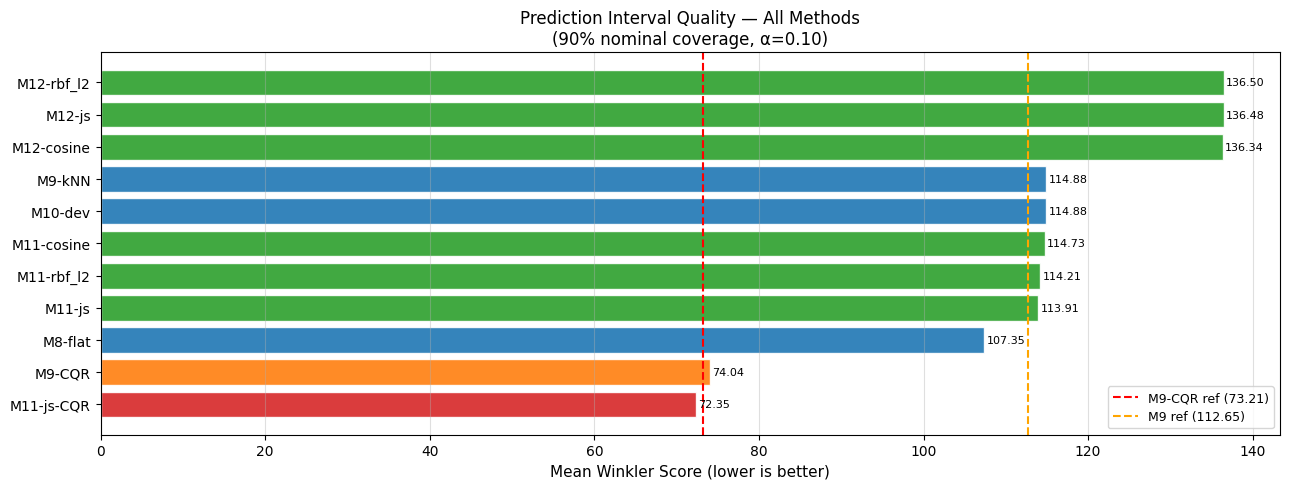

In [49]:
_color_map = {
    'baseline-conformal': 'C0', 'baseline-CQR': 'C1',
    'SVD-conformal': 'C2', 'SVD-CQR': 'C3'
}
_df_plot = df_results.reset_index().sort_values('Winkler')

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(
    _df_plot['Model'],
    _df_plot['Winkler'],
    color=[_color_map.get(t, 'gray') for t in _df_plot['Type']],
    edgecolor='white', alpha=0.9
)
ax.axvline(73.21, color='red',    ls='--', lw=1.5, label='M9-CQR ref (73.21)')
ax.axvline(112.65, color='orange', ls='--', lw=1.5, label='M9 ref (112.65)')
ax.set_xlabel('Mean Winkler Score (lower is better)', fontsize=11)
ax.set_title('Prediction Interval Quality — All Methods\n(90% nominal coverage, α=0.10)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, _df_plot['Winkler']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### D3 — SVD Scatter Plot (Component 1 vs 2, coloured by avg_proc_cost_pct decile)

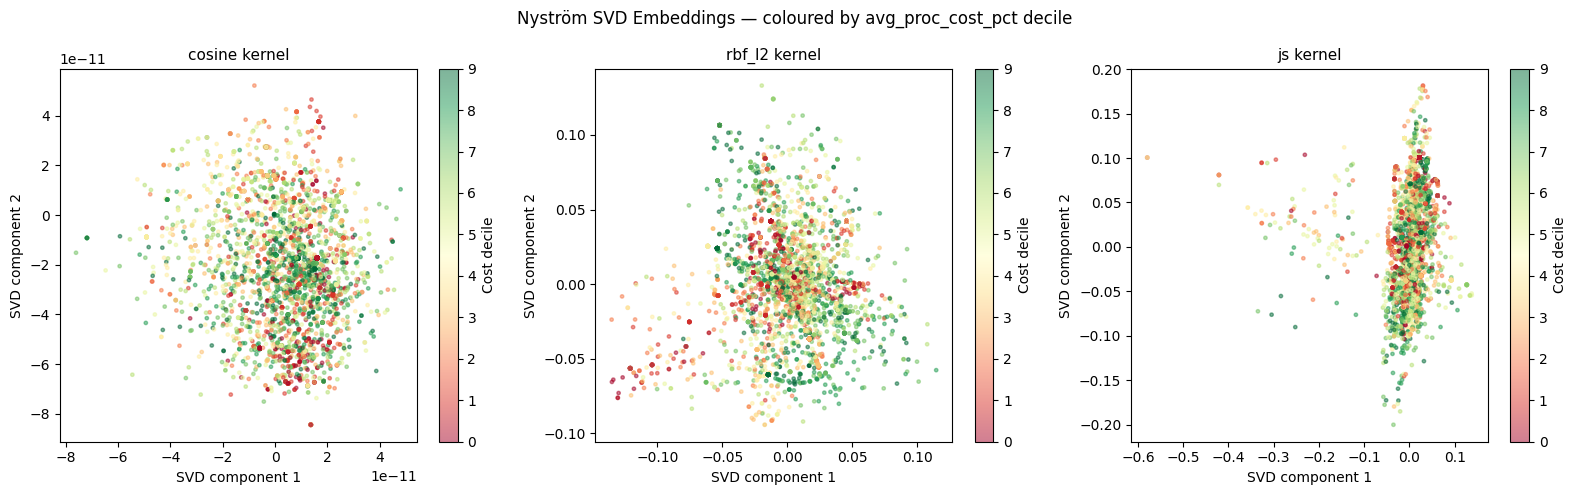

In [50]:
_decile = pd.qcut(df_svd['avg_proc_cost_pct'], q=10, labels=False, duplicates='drop')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, _metric in zip(axes, ['cosine', 'rbf_l2', 'js']):
    c1 = df_svd[f'svd_{_metric}_1'].values
    c2 = df_svd[f'svd_{_metric}_2'].values
    # Subsample for speed
    _idx = np.random.default_rng(0).choice(len(c1), min(4000, len(c1)), replace=False)
    sc = ax.scatter(c1[_idx], c2[_idx],
                    c=_decile.values[_idx], cmap='RdYlGn',
                    s=6, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Cost decile')
    ax.set_title(f'{_metric} kernel', fontsize=11)
    ax.set_xlabel('SVD component 1')
    ax.set_ylabel('SVD component 2')
fig.suptitle('Nyström SVD Embeddings — coloured by avg_proc_cost_pct decile', fontsize=12)
plt.tight_layout()
plt.show()

### D4 — Forecast Fan Chart: M9 vs Best SVD Variant (9 test merchants)

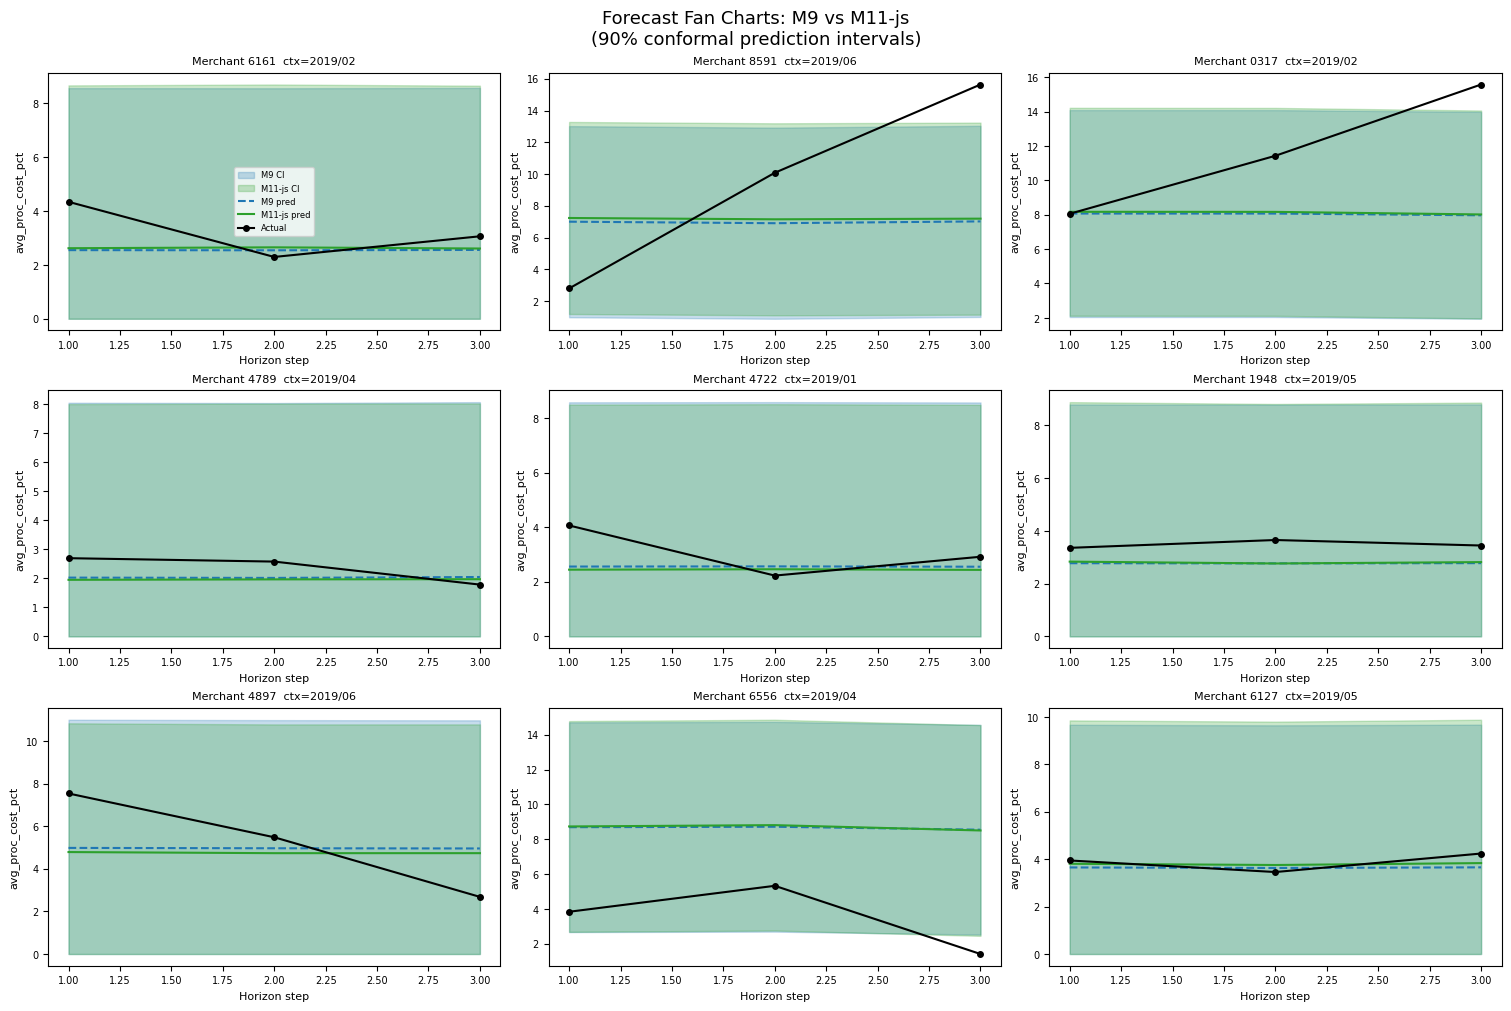

In [51]:
# Pick 9 test scenarios for fan chart display
_n_show = 9
_rng_vis = np.random.default_rng(7)
_show_idx = _rng_vis.choice(len(test_ci), size=min(_n_show, len(test_ci)), replace=False)

_best_res = svd_model_results[_best_label]

fig, axes = plt.subplots(3, 3, figsize=(15, 10), constrained_layout=True)
for plot_i, sc_i in enumerate(_show_idx):
    ax = axes[plot_i // 3][plot_i % 3]
    s = test_ci[sc_i]

    # Actual
    y_act = Y_te[sc_i]
    h_steps = np.arange(1, HORIZON_LEN + 1)

    # M9 conformal interval
    lo_m9 = res_m9['lo_te'][sc_i]
    hi_m9 = res_m9['hi_te'][sc_i]
    # Best SVD conformal interval
    lo_svd = _best_res['lo_te'][sc_i]
    hi_svd = _best_res['hi_te'][sc_i]
    # Point forecasts
    pt_m9  = res_m9['te_preds'][sc_i]
    pt_svd = _best_res['te_preds'][sc_i]

    ax.fill_between(h_steps, lo_m9,  hi_m9,  alpha=0.25, color='C0', label='M9 CI')
    ax.fill_between(h_steps, lo_svd, hi_svd, alpha=0.25, color='C2', label=f'{_best_label} CI')
    ax.plot(h_steps, pt_m9,  'C0--', lw=1.5, label='M9 pred')
    ax.plot(h_steps, pt_svd, 'C2-',  lw=1.5, label=f'{_best_label} pred')
    ax.plot(h_steps, y_act,  'k-o', ms=4, lw=1.5, label='Actual')

    _mid = s['merchant_id']
    _ctx = s['context_range'][1]
    ax.set_title(f'Merchant {str(_mid)[-4:]}  ctx={_ctx[0]}/{_ctx[1]:02d}', fontsize=8)
    ax.set_xlabel('Horizon step', fontsize=8)
    ax.set_ylabel('avg_proc_cost_pct', fontsize=8)
    ax.tick_params(labelsize=7)
    if plot_i == 0:
        ax.legend(fontsize=6, loc='best')

fig.suptitle(f'Forecast Fan Charts: M9 vs {_best_label}\n(90% conformal prediction intervals)', fontsize=13)
plt.show()

### D5 — Volatility-Stratified Winkler (Low vs High CoV)

Test scenarios — Low vol: 361  High vol: 0
Volatility  High      Low
Model                    
M11-js       NaN 113.9051
M9-kNN       NaN 114.8806


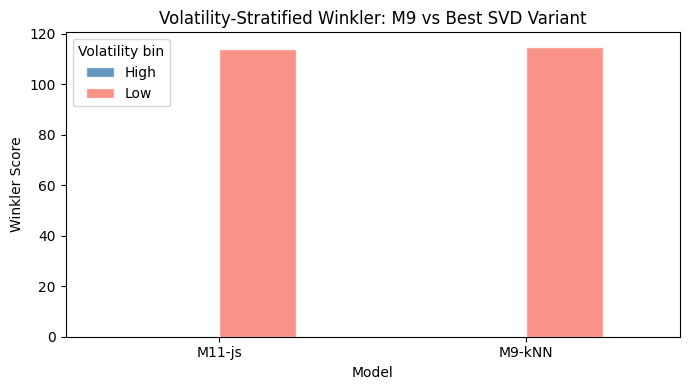

In [ ]:
_vol_bins = np.array([assign_vol_bin(s) for s in test_ci])
_low_mask  = _vol_bins == 'Low'
_high_mask = _vol_bins == 'High'
print(f'Test scenarios — Low vol: {_low_mask.sum()}  High vol: {_high_mask.sum()}')

def _winkler_mask(lo, hi, y, mask, alpha=0.10):
    return winkler(y[mask].ravel(), lo[mask].ravel(), hi[mask].ravel(), alpha)


_strat_rows = []
for _lbl, _res in [('M9-kNN', res_m9), (_best_label, svd_model_results[_best_label])]:
    for _vbin, _mask in [('Low', _low_mask), ('High', _high_mask)]:
        _ws = _winkler_mask(_res['lo_te'], _res['hi_te'], Y_te, _mask)
        _strat_rows.append({'Model': _lbl, 'Volatility': _vbin, 'Winkler': round(_ws, 4)})

df_strat = pd.DataFrame(_strat_rows)
print(df_strat.pivot(index='Model', columns='Volatility', values='Winkler').to_string())

# Grouped bar chart
_df_pivot = df_strat.pivot(index='Model', columns='Volatility', values='Winkler')
_df_pivot.plot(kind='bar', figsize=(7, 4), color=['steelblue', 'salmon'], alpha=0.85, edgecolor='white')
plt.ylabel('Winkler Score')
plt.title('Volatility-Stratified Winkler: M9 vs Best SVD Variant')
plt.legend(title='Volatility bin')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Summary

| Metric | Value |
|--------|-------|
| **Benchmark M9 Winkler** | 112.65 pp |
| **Benchmark M9-CQR Winkler** | 73.21 pp |
| **Best SVD conformal** | `svd_model_results[_best_label]["winkler"]` (see D1 table) |
| **Best SVD-CQR** | `_ws_svd_cqr` (see C4 output) |

**Observations:**
- Phase A: Nyström embeddings captured …% of variance in ≤ `SVD_RANK` dims (see eigenvalue decay plot, D1 table).
- Phase C: Augmented (4+SVD) vs replace (SVD-only) explored across cosine / RBF-L2 / JS kernels.
- Phase D: Winkler improvement over M9-CQR baseline indicates whether SVD cost-type histogram features improve interval sharpness.

> Lower Winkler = narrower intervals while maintaining ≥90% coverage.